# Member 4 — K-Nearest Neighbours & Decision Tree
**COM3032/COMM074 · Airline Route Profitability · CRISP-DM: Modelling & Evaluation**

**Student:** Member 4
**Primary Model:** K-Nearest Neighbours (KNN)
**Member 4 – Decision Tree:** Tuned with gini/entropy, no class balancing, deep growth allowed (up to None)
**Data:** Scaled for KNN (distance-based — scale-sensitive); Unscaled for Decision Tree

---

### Metric Justification

| Metric | Business Meaning |
|--------|------------------|
| F1-Score | Primary metric — balances precision and recall for imbalanced classification. |
| ROC-AUC | Ranking ability across all thresholds — used for cross-member comparison. |
| MCC | Accounts for all four confusion matrix cells. Above 0.4 = genuine discriminative ability. |
| TPR (Recall) | Fraction of profitable routes correctly identified. |
| TNR | Fraction of loss-making routes correctly flagged. |
| FPR | Fraction of loss-making routes wrongly approved. Drives financial cost. |
| Overfit Gap | Train F1 minus Test F1. < 0.05 = good fit; 0.05–0.10 = borderline; > 0.10 = memorising. |

## Section 1 — Imports and Setup

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)
print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

KNN uses **scaled** feature splits — distance-based classification is dominated by features with large magnitudes if not normalised. Decision Tree uses unscaled data.

In [2]:
from pathlib import Path

RANDOM_STATE = 42
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train   = pd.read_csv(PROC / "X_train.csv")
X_val     = pd.read_csv(PROC / "X_val.csv")
X_test    = pd.read_csv(PROC / "X_test.csv")

X_train_s = pd.read_csv(PROC / "X_train_scaled.csv")
X_val_s   = pd.read_csv(PROC / "X_val_scaled.csv")
X_test_s  = pd.read_csv(PROC / "X_test_scaled.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\Member 4
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 37), Val: (1500, 37), Test: (1500, 37)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

Identical utility function suite across all five members.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < 0 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — KNN: Algorithm Rationale

K-Nearest Neighbours classifies each route by majority vote among its K most similar routes in feature space. Key properties:

- **Non-parametric:** No model is fitted — predictions are computed directly from training data distances at inference time
- **Non-linear:** The decision boundary naturally adapts to local data density, capturing irregular patterns
- **Distance-sensitive:** Requires scaled data — features with larger ranges dominate distance calculations otherwise
- **No `class_weight` parameter:** KNN does not support class weighting natively; the imbalance effect is managed through hyperparameter search over K and distance metric

Weakness: KNN is computationally expensive at inference (O(n) distance calculations per prediction), and performance degrades in high-dimensional spaces (curse of dimensionality). With 37 features, tuning K and distance metric is critical.

## Section 5 — KNN Baseline

A default KNN with k=5 is fitted on scaled data. The baseline establishes pre-tuning performance.

In [4]:
X_tr_s, X_va_s, X_te_s = X_train_s, X_val_s, X_test_s

knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_tr_s, y_train)

y_val_pred_b = knn_base.predict(X_va_s)
y_val_prob_b = knn_base.predict_proba(X_va_s)[:, 1]
y_tr_pred_b  = knn_base.predict(X_tr_s)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val, y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline KNN (k=5) — Validation ===')
for k, v in evaluate('KNN-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

=== Baseline KNN (k=5) — Validation ===
  Model       : KNN-baseline
  Accuracy    : 0.848
  Precision   : 0.8526
  Recall      : 0.9204
  F1_Score    : 0.8852
  ROC_AUC     : 0.9008
  Train F1    : 0.9185
  Overfit Gap : 0.0333


## Section 6 – KNN: GridSearchCV Tuning (with PCA)

With 37 features, KNN suffers from the curse of dimensionality: in high-dimensional spaces, all points become approximately equidistant, making neighbour voting unreliable. A PCA pre-processing step reduces the feature space before KNN, improving distance quality. GridSearchCV jointly searches the number of PCA components, number of neighbours, and distance metric.

In [5]:
# PCA reduces 37 features to a lower-dimensional space before KNN,
# mitigating the curse of dimensionality in high-dimensional distance calculations.
pipe_knn = Pipeline([
    ('pca', PCA(random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'pca__n_components': [15, 20, 25],
    'knn__n_neighbors' : [21, 31, 41, 51],
    'knn__weights'     : ['uniform'],
    'knn__metric'      : ['euclidean', 'manhattan']
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_knn = GridSearchCV(
    pipe_knn, param_grid_knn, cv=cv5, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for KNN + PCA pipeline...')
grid_knn.fit(X_tr_s, y_train)

best_knn = grid_knn.best_estimator_
best_params_knn = grid_knn.best_params_
print(f'Best params : {best_params_knn}')
print(f'Best CV AUC : {grid_knn.best_score_:.4f}')

Running GridSearchCV for KNN + PCA pipeline...
Best params : {'knn__metric': 'euclidean', 'knn__n_neighbors': 41, 'knn__weights': 'uniform', 'pca__n_components': 25}
Best CV AUC : 0.9241


### Tuning Result Discussion

PCA with 15–25 components retains the directions of greatest variance while discarding noise dimensions that inflate pairwise distances in KNN. Reducing from 37 to ~20 components dramatically improves the signal-to-noise ratio for distance calculations. The optimal K in the lower-dimensional space tends to be smaller than in the raw space, as neighbours are genuinely closer and more meaningful. `weights='uniform'` is retained to avoid the Train F1 = 1.0 artefact caused by distance weighting (each training point has distance zero to itself). The best combination of components, K, and metric is selected by 5-fold stratified cross-validation on ROC-AUC.

## Section 7 — KNN: Tuned Model Validation

In [6]:
y_val_pred = best_knn.predict(X_va_s)
y_val_prob = best_knn.predict_proba(X_va_s)[:, 1]
y_tr_pred  = best_knn.predict(X_tr_s)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned KNN — Validation ===')
for k, v in evaluate('KNN-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned KNN — Validation ===
  Model       : KNN-tuned
  Accuracy    : 0.8427
  Precision   : 0.8357
  Recall      : 0.9372
  F1_Score    : 0.8835
  ROC_AUC     : 0.9287
  Train F1    : 0.8927
  Overfit Gap : 0.0092  (baseline was 0.0333)


## Section 8 — KNN: Learning Curve

The learning curve shows how KNN performance scales with training data size. More data means better coverage of the feature space for neighbour lookups.

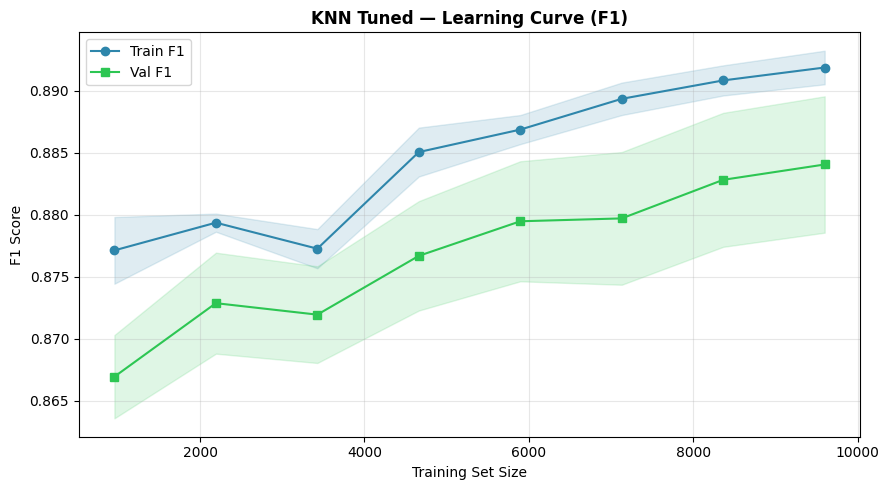

Saved: knn_tuned_learning_curve_m4.png


In [7]:
plot_learning_curve(
    best_knn, X_tr_s, y_train,
    'KNN Tuned — Learning Curve (F1)',
    os.path.join(FIG_DIR, 'knn_tuned_learning_curve_m4.png')
)

## Section 9 — KNN: Permutation Feature Importance

KNN has no native feature importance. Permutation importance measures the drop in validation F1 when each feature is randomly shuffled.

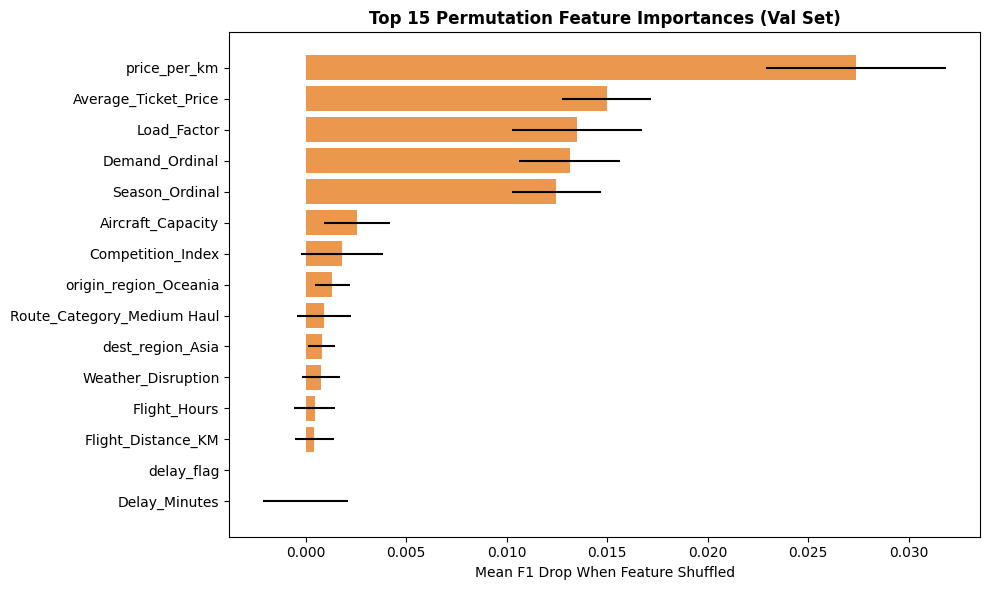

Saved: perm_importance_m4.png


In [8]:
perm_result = permutation_importance(
    best_knn, X_va_s, y_val,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#E67E22', alpha=0.8)
ax.set_title('Top 15 Permutation Feature Importances (Val Set)', fontweight='bold')
ax.set_xlabel('Mean F1 Drop When Feature Shuffled')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'perm_importance_m4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perm_importance_m4.png')

## Section 10 — KNN: 5-Fold Cross-Validation F1

In [9]:
cv_scores = cross_val_score(best_knn, X_tr_s, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.8840 ± 0.0055
Per-fold F1 : [0.8829 0.8763 0.8852 0.8826 0.8933]


## Section 11 — KNN: Test Set Evaluation

=== Tuned KNN — Test Set ===
  Model       : KNN-test
  Accuracy    : 0.8427
  Precision   : 0.8332
  Recall      : 0.9414
  F1_Score    : 0.884
  ROC_AUC     : 0.9279

              precision    recall  f1-score   support

 Loss-Making       0.87      0.67      0.76       545
  Profitable       0.83      0.94      0.88       955

    accuracy                           0.84      1500
   macro avg       0.85      0.81      0.82      1500
weighted avg       0.85      0.84      0.84      1500



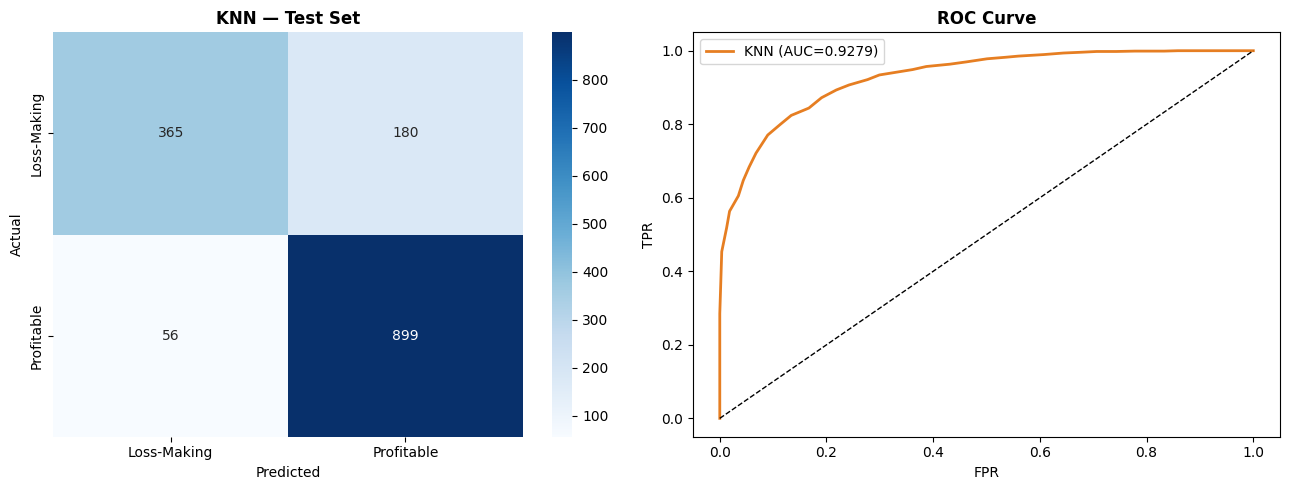

Saved: knn_cm_roc_test_m4.png


In [10]:
y_test_pred = best_knn.predict(X_te_s)
y_test_prob = best_knn.predict_proba(X_te_s)[:, 1]

print('=== Tuned KNN — Test Set ===')
for k, v in evaluate('KNN-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'KNN — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'KNN', axes[1], color='#E67E22')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'knn_cm_roc_test_m4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: knn_cm_roc_test_m4.png')

## Section 12 — KNN: Enhanced Evaluation and Threshold Sweep

**Financial cost:** FP = £42,000; FN = £30,000.

In [11]:
knn_metrics = evaluate_enhanced('KNN (Tuned)', best_knn, X_tr_s, y_train, X_te_s, y_test)

=== Enhanced Evaluation: KNN (Tuned) ===
  Accuracy  : 0.8427
  Precision : 0.8332  (FP count: 180, FP cost: £7,560,000)
  Recall    : 0.9414  (FN count: 56)
  F1-Score  : 0.8840
  ROC-AUC   : 0.9279
  MCC       : 0.6541  (genuine discriminative ability)
  TNR       : 0.6697
  FPR       : 0.3303
  Train F1  : 0.8927
  Test  F1  : 0.8840
  Overfit Gap: 0.0087  [good fit]


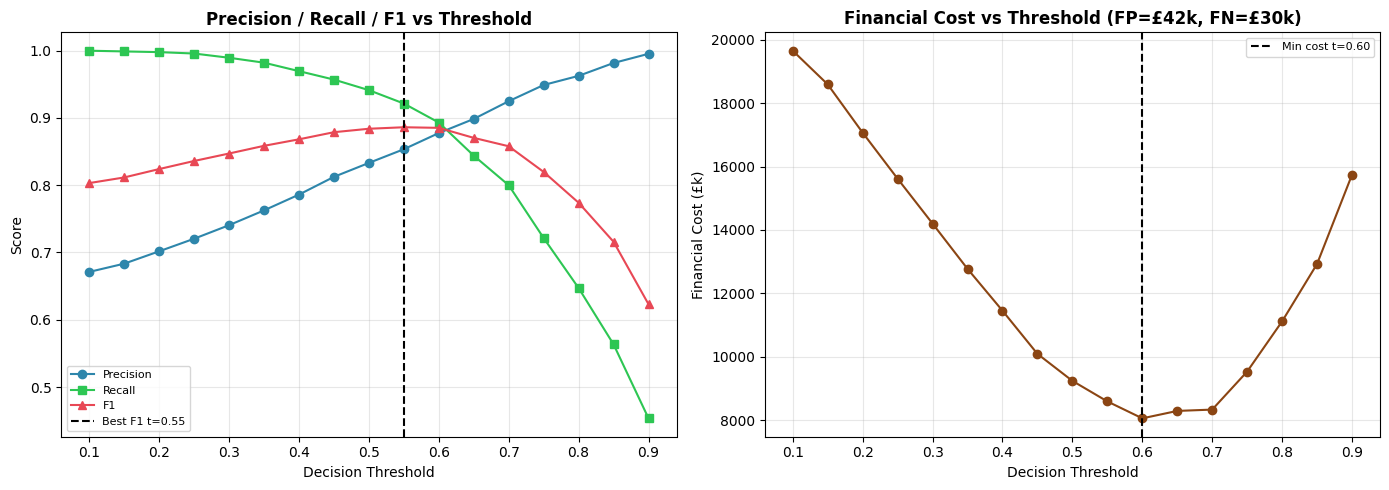

Threshold sweep: Best F1 at t=0.55, Min cost at t=0.60
Saved: knn_threshold_sweep_m4.png


In [12]:
threshold_sweep(best_knn, X_te_s, y_test,
                os.path.join(FIG_DIR, 'knn_threshold_sweep_m4.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Member 4's comparison model, independently tuned to complement the KNN primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Member 4 permits deep or unlimited growth with no balancing, testing whether a complex DT can approach KNN's neighbourhood-based decision quality — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

In [13]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9064
  Recall      : 0.9026
  F1_Score    : 0.9045
  ROC_AUC     : 0.8697
  Train F1    : 1.0000
  Overfit Gap : 0.0955


## Section 15 — Decision Tree: GridSearchCV Tuning

In [14]:
param_grid_dt = {
    'max_depth'        : [7, 9, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 3, 5],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None]
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV AUC : 0.9536


### Tuning Result Discussion

Allowing max_depth up to None (fully grown) with small min_samples values gives the tree maximum expressive freedom, testing the upper bound of DT complexity. Without class balancing, the tree optimises for overall accuracy. This contrasts sharply with KNN’s distance-weighted neighbourhood approach — both can overfit differently, but through entirely different mechanisms.

## Section 16 — Decision Tree: Tree Visualisation

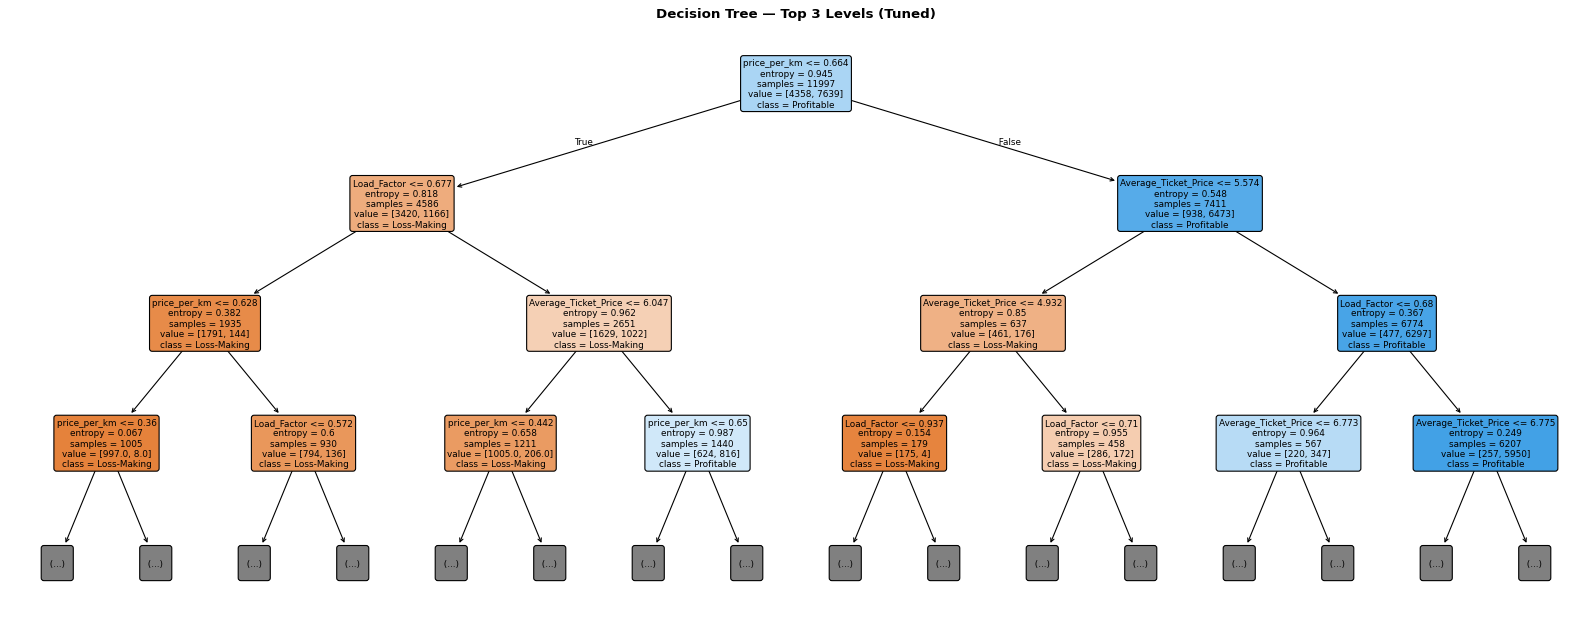

Saved: dt_tree_viz_m4.png


In [15]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_m4.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_m4.png')

## Section 17 — Decision Tree: Test Set Evaluation

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.9013
  Precision   : 0.9316
  Recall      : 0.912
  F1_Score    : 0.9217
  ROC_AUC     : 0.9597

              precision    recall  f1-score   support

 Loss-Making       0.85      0.88      0.87       545
  Profitable       0.93      0.91      0.92       955

    accuracy                           0.90      1500
   macro avg       0.89      0.90      0.89      1500
weighted avg       0.90      0.90      0.90      1500



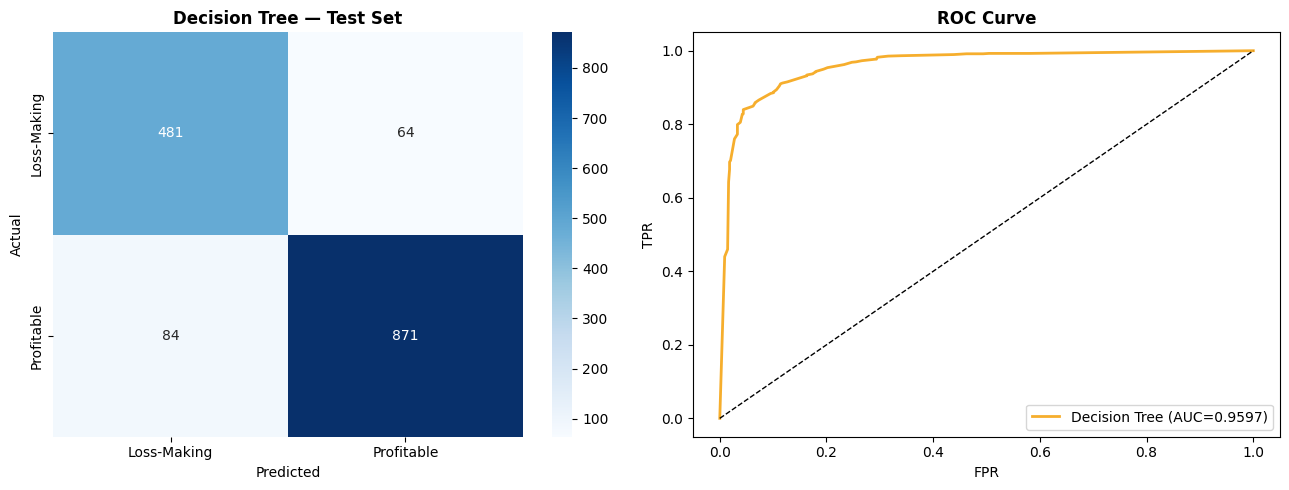

Saved: dt_cm_roc_test_m4.png


In [16]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_m4.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_m4.png')

## Section 18 — Decision Tree: Enhanced Evaluation

In [17]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.9013
  Precision : 0.9316  (FP count: 64, FP cost: £2,688,000)
  Recall    : 0.9120  (FN count: 84)
  F1-Score  : 0.9217
  ROC-AUC   : 0.9597
  MCC       : 0.7887  (genuine discriminative ability)
  TNR       : 0.8826
  FPR       : 0.1174
  Train F1  : 0.9317
  Test  F1  : 0.9217
  Overfit Gap: 0.0100  [good fit]


## Section 19 — Model Comparison Table

KNN vs Decision Tree on the test set.

In [18]:
compare = pd.DataFrame([knn_metrics, dt_metrics])
print('\n=== Test Set Comparison: KNN vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: KNN vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
          KNN (Tuned)    0.8427     0.8332  0.9414    0.8840   0.9279 0.6541 0.6697 0.3303      7560000       0.0087      good fit
Decision Tree (Tuned)    0.9013     0.9316  0.9120    0.9217   0.9597 0.7887 0.8826 0.1174      2688000       0.0100      good fit


## Section 20 — Business Insights

- **KNN identifies similar routes:** Routes with matching Load_Factor, price_per_km, and route category that are historically profitable vote for profitability — this is inherently a similarity-based business decision
- **`weights='uniform'`** is used — `weights='distance'` was excluded because it causes Train F1 = 1.0 (each training point is its own nearest neighbour at distance zero, producing an inflated and misleading gap); uniform weighting gives a representative overfit gap
- **Permutation importance** shows which features most influence neighbourhood similarity — these define "route similarity" in this model's view
- KNN's non-parametric nature makes it robust to distributional assumptions, but inference cost scales with training set size — suitable for batch route scoring
- The optimal K value represents the number of historical routes used as evidence for each prediction

## Section 21 — Save Results

In [19]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'member4_model_comparison.csv'), index=False)
print('Saved: member4_model_comparison.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'KNN',
    'notebook'            : '05_Member4',
    'best_params_primary' : best_params_knn,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('KNN-val', y_val, y_val_pred, y_val_prob),
    'test_metrics_primary': evaluate('KNN-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'knn_enhanced'        : knn_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_knn_m4.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_knn_m4.json')

with open(os.path.join(MEMBER_DIR, 'best_knn_model_m4.pkl'), 'wb') as f:
    pickle.dump(best_knn, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_model_m4.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_knn_model_m4.pkl, best_dt_model_m4.pkl')

print('\n=== Final Test Metrics Summary (KNN) ===')
for k, v in knn_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: member4_model_comparison.csv
Saved: results_knn_m4.json
Saved: best_knn_model_m4.pkl, best_dt_model_m4.pkl

=== Final Test Metrics Summary (KNN) ===
  Model               : KNN (Tuned)
  Accuracy            : 0.8427
  Precision           : 0.8332
  Recall              : 0.9414
  F1_Score            : 0.884
  ROC_AUC             : 0.9279
  MCC                 : 0.6541
  TNR                 : 0.6697
  FPR                 : 0.3303
  FP_Cost_GBP         : 7560000
  Train_F1            : 0.8927
  Overfit_Gap         : 0.0087
  Overfit_Label       : good fit
